In [1]:
# 02_EDA.ipynb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import os

DATA_PATH = "../data"
TARGET_COL = "isFraud"
sns.set_style('whitegrid')

In [2]:
# 1. Load cleaned merged data

df = pd.read_csv(os.path.join(DATA_PATH, 'train_merged_clean.csv'))

print("Shape:", df.shape)
display(df.head())

Shape: (590540, 360)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_20,id_28,id_29,id_31,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,144.0,New,NotFound,samsung browser 6.2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [3]:
# --- Initial Data Overview ---

# Check Missing Values
na_info = pd.DataFrame({
    'Total NA': df.isnull().sum(),
    'NA Ratio': df.isnull().mean()
}).sort_values(by='NA Ratio', ascending=False)
display(na_info[na_info['NA Ratio'] > 0].head(10))

,Total NA,NA Ratio
DeviceInfo,471874,0.799055
id_13,463220,0.784401
id_16,461200,0.780980
V276,460110,0.779134
V262,460110,0.779134
V249,460110,0.779134
V252,460110,0.779134
V253,460110,0.779134
V254,460110,0.779134
V257,460110,0.779134


In [4]:
# Target Class Distribution (Imbalance Check)
print("\nTarget Class Distribution:")
print(df[TARGET_COL].value_counts(normalize=True))

# Separate Data Types
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Remove target and TransactionID from numeric columns if present
if TARGET_COL in numeric_cols:
    numeric_cols.remove(TARGET_COL)
if 'TransactionID' in numeric_cols:
    numeric_cols.remove('TransactionID')

# Print counts 
print("\nNumber of numeric columns: " + str(len(numeric_cols)))
print("Number of categorical columns: " + str(len(categorical_cols)))



Target Class Distribution:
isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64

Number of numeric columns: 332
Number of categorical columns: 26


In [5]:
# --- Function for Categorical Fraud Rate ---
def fraud_rate_by_category(col, data):
    """Calculates and returns fraud rate ('mean' of isFraud) for a given column."""
    temp = data.groupby(col)[TARGET_COL].agg(['count', 'mean']).sort_values(by='mean', ascending=False)
    temp.rename(columns={'mean': 'fraud_rate'}, inplace=True)
    return temp

C:\Users\hp\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


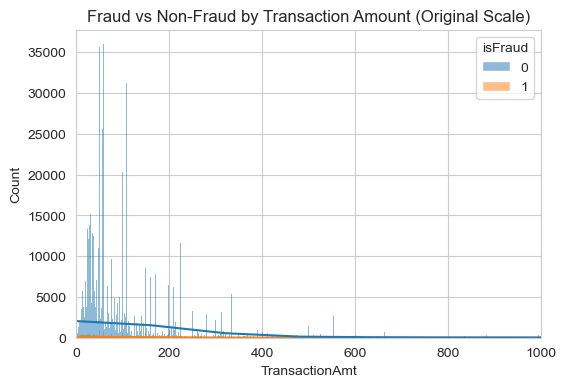

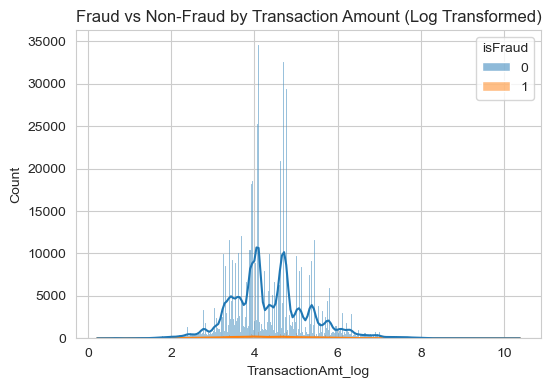

In [6]:
# --- Numerical Feature Analysis ---

# Visualize TransactionAmt distribution (Highly Skewed)
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='TransactionAmt', hue=TARGET_COL, kde=True, common_norm=False)
plt.title("Fraud vs Non-Fraud by Transaction Amount (Original Scale)")
plt.xlim(0, 1000) # Zooming in on the common range
plt.show()

# Visualize TransactionAmt with Log Transform (Shows what Feature Engineering will do)
df['TransactionAmt_log'] = np.log1p(df['TransactionAmt'])
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='TransactionAmt_log', hue=TARGET_COL, kde=True, common_norm=False)
plt.title("Fraud vs Non-Fraud by Transaction Amount (Log Transformed)")
plt.show()

In [7]:
# --- Time-Series Feature Analysis (CRITICAL) ---

# Convert TransactionDT to time features (as was done in the FE notebook)
df['TransTime'] = (datetime.datetime(2017, 12, 1) + pd.to_timedelta(df['TransactionDT'], unit='s'))
df['hour'] = df['TransTime'].dt.hour
df['dayofweek'] = df['TransTime'].dt.dayofweek # Monday=0, Sunday=6

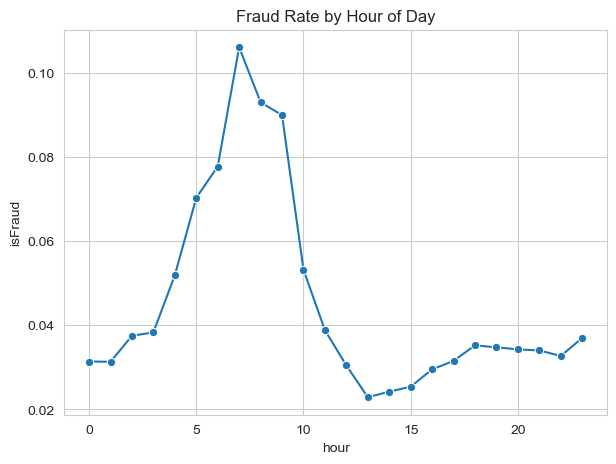

In [8]:
# Fraud Rate by Hour of Day
hourly_fraud = df.groupby('hour')[TARGET_COL].mean().reset_index()
plt.figure(figsize=(7,5))
sns.lineplot(data=hourly_fraud, x='hour', y=TARGET_COL, marker='o')
plt.title('Fraud Rate by Hour of Day')
plt.show()

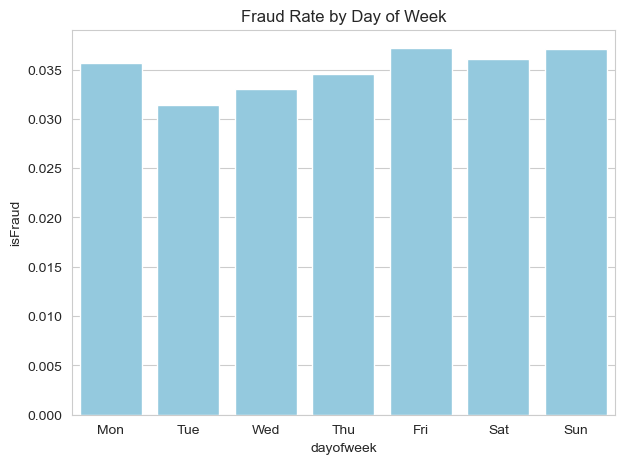

In [9]:
# Fraud Rate by Day of Week
dayofweek_fraud = df.groupby('dayofweek')[TARGET_COL].mean().reset_index()
dayofweek_fraud['dayofweek'] = dayofweek_fraud['dayofweek'].map({
    0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'
})
plt.figure(figsize=(7,5))
sns.barplot(data=dayofweek_fraud, x='dayofweek', y=TARGET_COL, color='skyblue')
plt.title('Fraud Rate by Day of Week')
plt.show()

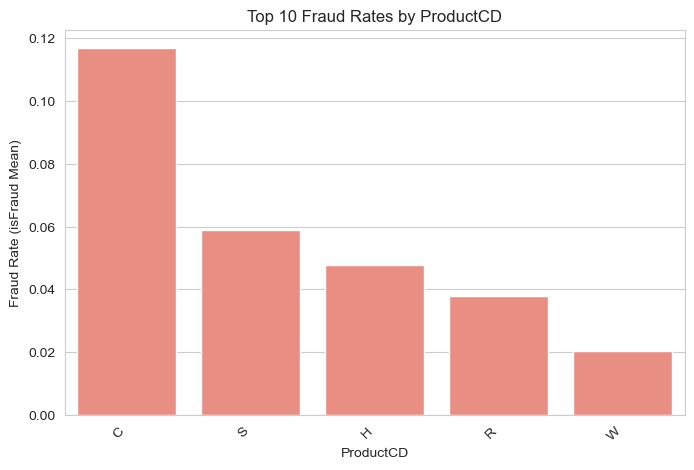


Top 10 Fraud Rates for ProductCD:


,count,fraud_rate
ProductCD,,
C,68519,0.116873
S,11628,0.058996
H,33024,0.047662
R,37699,0.037826
W,439670,0.020399


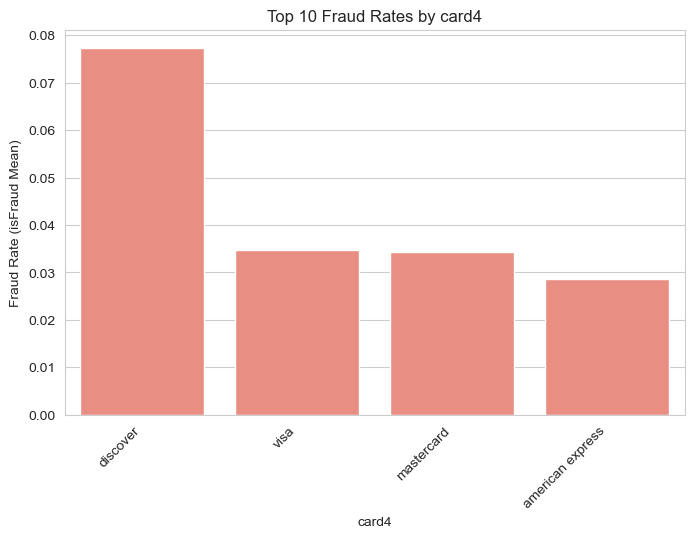


Top 10 Fraud Rates for card4:


,count,fraud_rate
card4,,
discover,6651,0.077282
visa,384767,0.034756
mastercard,189217,0.034331
american express,8328,0.028698


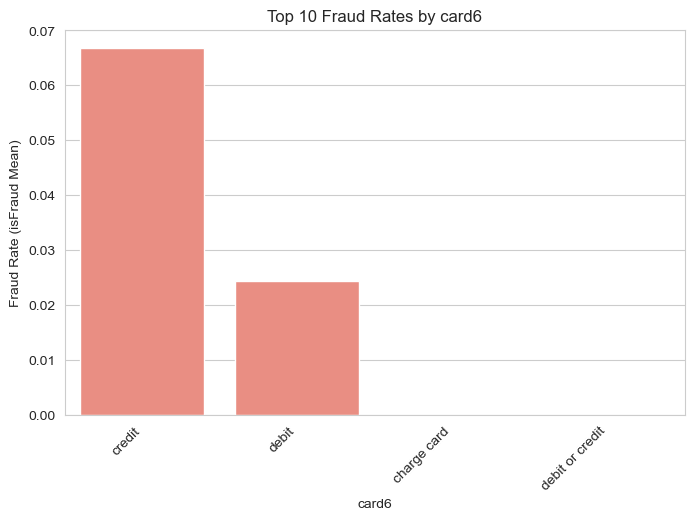


Top 10 Fraud Rates for card6:


,count,fraud_rate
card6,,
credit,148986,0.066785
debit,439938,0.024263
charge card,15,0.000000
debit or credit,30,0.000000


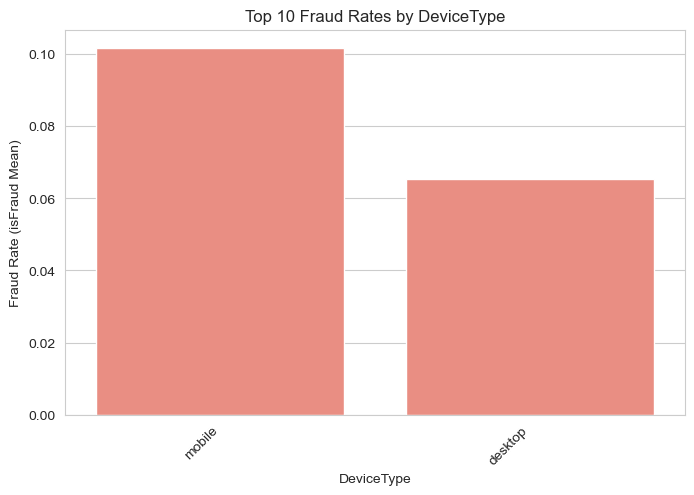


Top 10 Fraud Rates for DeviceType:


,count,fraud_rate
DeviceType,,
mobile,55645,0.101662
desktop,85165,0.065215


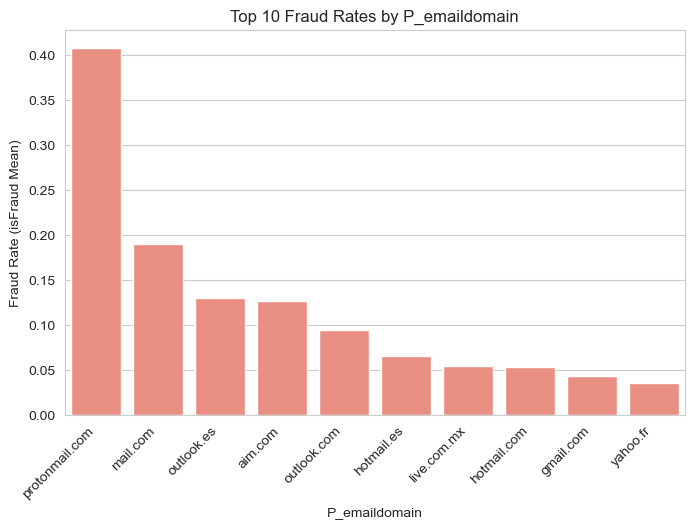


Top 10 Fraud Rates for P_emaildomain:


,count,fraud_rate
P_emaildomain,,
protonmail.com,76,0.407895
mail.com,559,0.189624
outlook.es,438,0.130137
aim.com,315,0.126984
outlook.com,5096,0.094584
hotmail.es,305,0.065574
live.com.mx,749,0.054740
hotmail.com,45250,0.052950
gmail.com,228355,0.043542


In [10]:
# --- Categorical Feature Analysis ---

important_cat_cols = ['ProductCD', 'card4', 'card6', 'DeviceType', 'P_emaildomain']

for col in important_cat_cols:
    if col in df.columns:
        counts = fraud_rate_by_category(col, df)
        
        # Visualize Top 10 categories by fraud rate
        plt.figure(figsize=(8, 5))
        sns.barplot(x=counts.index[:10], y='fraud_rate', data=counts.head(10), color='salmon')
        plt.title(f'Top 10 Fraud Rates by {col}')
        plt.ylabel('Fraud Rate (isFraud Mean)')
        plt.xticks(rotation=45, ha='right')
        plt.show()
        
        # Display raw counts for high-level insight
        print(f"\nTop 10 Fraud Rates for {col}:")
        display(counts.head(10))

In [11]:
# --- Focused Correlation Analysis (Identifying Collinearity) ---

# Get top 20 most positively correlated features (excluding IDs and target)
corr = df[numeric_cols + [TARGET_COL]].corr()
target_corr = corr[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)
top_corr_features = target_corr.head(20).index.tolist()

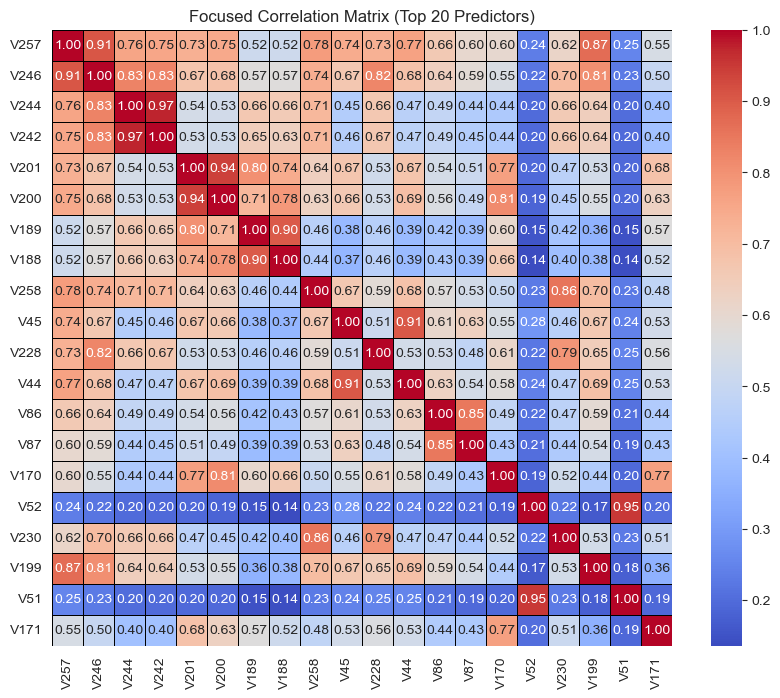

In [13]:
## Calculate and visualize the correlation matrix for only the top 20 features
if top_corr_features:
    top_corr_matrix = df[top_corr_features].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(top_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='black')
    plt.title('Focused Correlation Matrix (Top 20 Predictors)')
    plt.show()


In [15]:
# Final thoughts 
print("\n--- EDA Insights and Next Steps ---")
print("* Imbalance: The target is highly imbalanced (approx. 3.5% Fraud).")
print("* Numerical: TransactionAmt is highly skewed (log transformation is necessary).")
print("* Time: There are clear hourly and weekly patterns in fraud rate.")
print("* Categorical: Features like ProductCD, card6, and P_emaildomain show strong differences in fraud rates, suggesting they are very predictive.")
print("\nNext notebook (03_feature_engineering) must implement log-transform, time features, and use specialized encoding (like Target or Frequency Encoding) for the predictive categorical columns.")



--- EDA Insights and Next Steps ---
* Imbalance: The target is highly imbalanced (approx. 3.5% Fraud).
* Numerical: TransactionAmt is highly skewed (log transformation is necessary).
* Time: There are clear hourly and weekly patterns in fraud rate.
* Categorical: Features like ProductCD, card6, and P_emaildomain show strong differences in fraud rates, suggesting they are very predictive.

Next notebook (03_feature_engineering) must implement log-transform, time features, and use specialized encoding (like Target or Frequency Encoding) for the predictive categorical columns.
